# Data Preprocessing & Demographic Analysis
Fokus utama notebook ini adalah:
1. Membersihkan data (handling missing values).
2. Mengeksplorasi data demografi (`Genre` dan `Âge`) untuk mendukung argumen **Algorithmic Fairness**.
3. Melihat korelasi awal antara demografi dan jenis penyakit.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Advanced Modeling & Tuning
import optuna
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING) # Supress optuna spam


## Configuration & Setup

In [16]:
# Set visual theme
sns.set_theme(style='whitegrid')

# Load dataset
df = pd.read_csv('data.csv', sep=';')
print(f'Ukuran dataset awal: {df.shape}')
display(df[['Centre de santé', 'Genre (Gender)', 'Âge (Age)', 'Poids (Weight)']].head())


Ukuran dataset awal: (300, 109)


,Centre de santé,Genre (Gender),Âge (Age),Poids (Weight)
0,CMA de DO,Femme,18,55.0
1,CMA de DO,Homme,26,120.0
2,CMA de DO,Homme,25,63.0
3,CMA de DO,Homme,3,12.0
4,CMA de DO,Homme,8,24.0


## 1. Data Preprocessing Dasar
Kita akan merapikan nama kolom dan melihat apakah ada missing values pada kolom demografi penting.

In [17]:
# Melihat Missing Values pada kolom demografi
demo_cols = ['Genre (Gender)', 'Âge (Age)', 'Poids (Weight)', 'Centre de santé']
print('Missing values pada Demografi:')
print(df[demo_cols].isnull().sum())

# Standarisasi kolom Gender untuk konsistensi
if 'Genre (Gender)' in df.columns:
    df['Genre (Gender)'] = df['Genre (Gender)'].str.strip().str.title()


Missing values pada Demografi:
Genre (Gender)       2
Âge (Age)            0
Poids (Weight)     104
Centre de santé      0
dtype: int64


## 2. Demographic Data Exploration
Visualisasi distribusi Gender dan Umur.

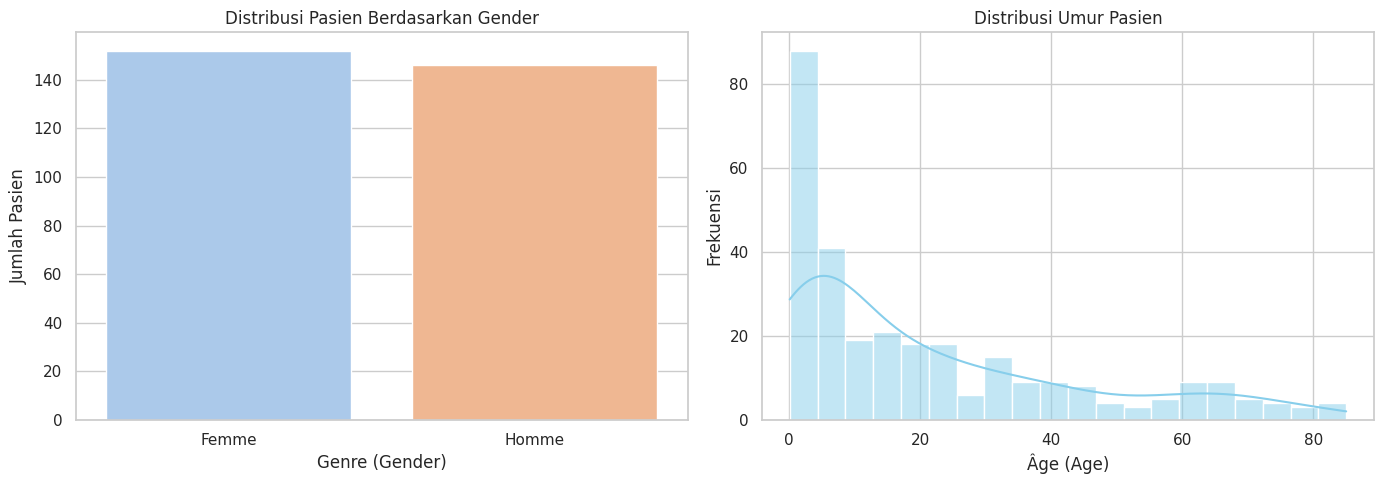

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi Gender
sns.countplot(data=df, x='Genre (Gender)', ax=axes[0], palette='pastel')
axes[0].set_title('Distribusi Pasien Berdasarkan Gender')
axes[0].set_ylabel('Jumlah Pasien')

# Plot 2: Distribusi Umur
sns.histplot(data=pd.to_numeric(df['Âge (Age)'].astype(str).str.replace(',', '.'), errors='coerce'), kde=True, ax=axes[1], color='skyblue', bins=20)
axes[1].set_title('Distribusi Umur Pasien')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


## 3. Feature Engineering: Transformasi Usia (Age Binning)
Mengingat distribusi usia yang sangat skew ke anak-anak, untuk keperluan **Algorithmic Fairness**, kita akan membagi pasien ke dalam beberapa kelompok usia:
* Balita (0 - 5 tahun)
* Anak-anak (6 - 12 tahun)
* Remaja (13 - 18 tahun)
* Dewasa (19 - 59 tahun)
* Lansia (60+ tahun)

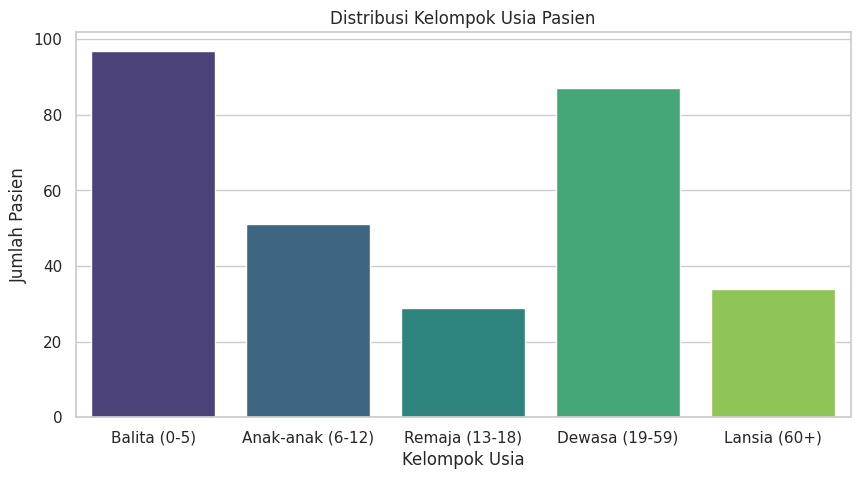

In [19]:
# Membersihkan dan memastikan kolom Age berbentuk numerik
# Mengganti koma dengan titik (jika ada) dan mengubah ke float
df['Âge (Age)'] = pd.to_numeric(df['Âge (Age)'].astype(str).str.replace(',', '.'), errors='coerce')

# Membuat binning
bins = [-1, 5, 12, 18, 59, 100]
labels = ['Balita (0-5)', 'Anak-anak (6-12)', 'Remaja (13-18)', 'Dewasa (19-59)', 'Lansia (60+)']
df['Age_Group'] = pd.cut(df['Âge (Age)'], bins=bins, labels=labels)

# Visualisasi
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Age_Group', palette='viridis', order=labels)
plt.title('Distribusi Kelompok Usia Pasien')
plt.ylabel('Jumlah Pasien')
plt.xlabel('Kelompok Usia')
plt.show()


## 4. Missing Value Handling Pipeline
Berdasarkan evaluasi, kita akan melakukan 3 langkah *cleaning*:
1. **Drop Kolom:** Membuang kolom yang > 60% kosong.
2. **Imputasi Gejala (Symptoms):** Mengisi NaN pada kolom berformat 'OUI'/'NON' dengan 'NON', lalu diubah menjadi 1 dan 0.
3. **Imputasi Numerik Klinis:** Mengisi NaN pada kolom pengukuran seperti Berat Badan menggunakan nilai Median.

In [20]:
# 1. DROP KOLOM DENGAN > 60% MISSING VALUES
threshold = 0.60 * len(df)
cols_to_drop = df.columns[df.isnull().sum() > threshold]
print(f'Mendrop {len(cols_to_drop)} kolom dengan Missing Values > 60%')
df.drop(columns=cols_to_drop, inplace=True)

# 2. IMPUTASI GEJALA (SYMPTOMS) -> OUI/NON to 1/0
# Deteksi otomatis kolom yang isinya dominan OUI/NON
symptom_cols = []
for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].dropna().astype(str).str.upper().unique()
        # Jika nilai uniknya mengandung 'OUI' atau 'NON'
        if any(val in ['OUI', 'NON'] for val in unique_vals):
            symptom_cols.append(col)

print(f'Mendeteksi {len(symptom_cols)} kolom gejala. Melakukan imputasi dan binarisasi...')
for col in symptom_cols:
    # Isi NaN dengan 'NON' (Asumsi: tidak diisi berarti tidak ada gejala)
    df[col] = df[col].fillna('NON')
    # Map ke 1 dan 0
    df[col] = df[col].map(lambda x: 1 if str(x).upper() == 'OUI' else 0)

# 3. IMPUTASI NUMERIK (Berat Badan dll)
# Kita bersihkan dulu kolom Poids (Weight) jika bentuknya string
if df['Poids (Weight)'].dtype == 'object':
    df['Poids (Weight)'] = pd.to_numeric(df['Poids (Weight)'].astype(str).str.replace(',', '.'), errors='coerce')

# Imputasi berat badan menggunakan median berdasarkan Kelompok Usia (Age_Group)
df['Poids (Weight)'] = df.groupby('Age_Group')['Poids (Weight)'].transform(lambda x: x.fillna(x.median()))
# Jika masih ada sisa (misal grup usia tidak punya median), isi dengan median global
df['Poids (Weight)'] = df['Poids (Weight)'].fillna(df['Poids (Weight)'].median())

# Sisa kolom numerik lainnya kita isi dengan median global
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print('=== STATUS MISSING VALUES SETELAH CLEANING ===')
print(f'Total Missing Values tersisa di data numerik & gejala: {df[numeric_cols].isnull().sum().sum()}')


Mendrop 3 kolom dengan Missing Values > 60%
Mendeteksi 79 kolom gejala. Melakukan imputasi dan binarisasi...
=== STATUS MISSING VALUES SETELAH CLEANING ===
Total Missing Values tersisa di data numerik & gejala: 0


## 5. Analisis Target Penyakit (Maladies diagnostiquées)
Dari eksplorasi awal, kita tahu bahwa target penyakit ada di kolom-kolom yang diawali dengan `Maladies diagnostiquées`. Mari kita lihat frekuensi masing-masing penyakit.

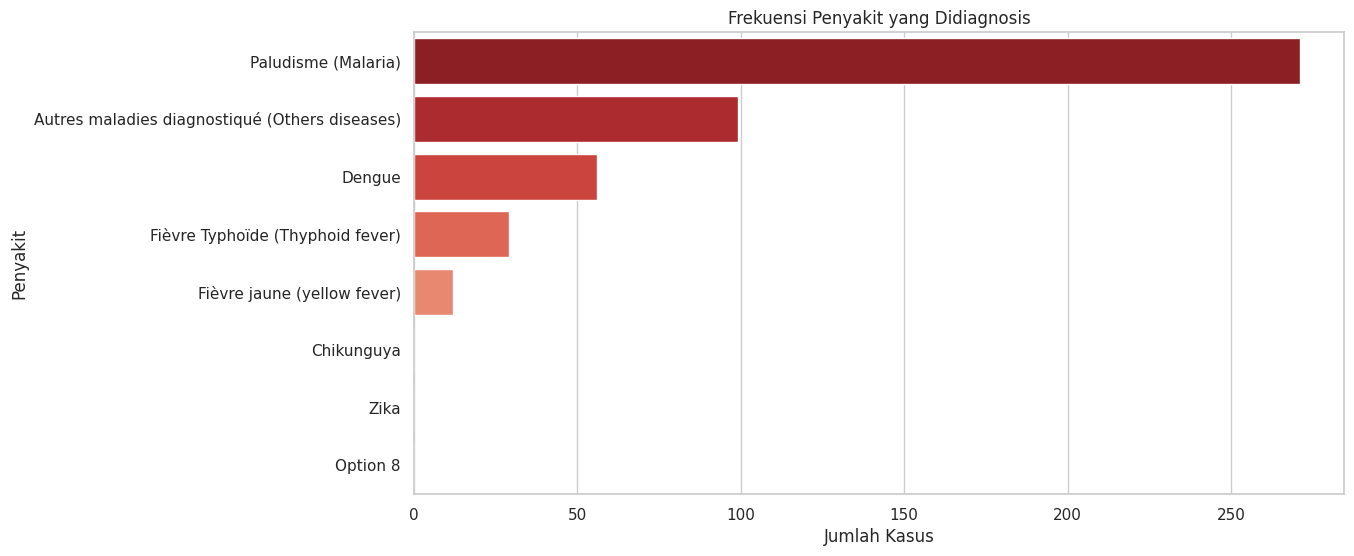

In [21]:
target_cols = [c for c in df.columns if 'Maladies diagnostiquées/' in c]

# Ubah target menjadi numerik (0/1) untuk keamanan
for col in target_cols:
    df[col] = df[col].map(lambda x: 1 if x in ['Yes', 'Oui', '1', 1, 1.0, True] else 0)

target_sums = df[target_cols].sum().sort_values(ascending=False)
target_names = [col.split('/')[-1] for col in target_sums.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=target_sums.values, y=target_names, palette='Reds_r')
plt.title('Frekuensi Penyakit yang Didiagnosis')
plt.xlabel('Jumlah Kasus')
plt.ylabel('Penyakit')
plt.show()


## 6. Analisis Korelasi: Penyakit vs Gejala Top 10
Kita akan mencari 10 gejala teratas yang memiliki korelasi terkuat dengan penyakit utama (misal: Malaria dan Dengue).

--- Top 10 Gejala Berkorelasi dengan Paludisme (Malaria) ---


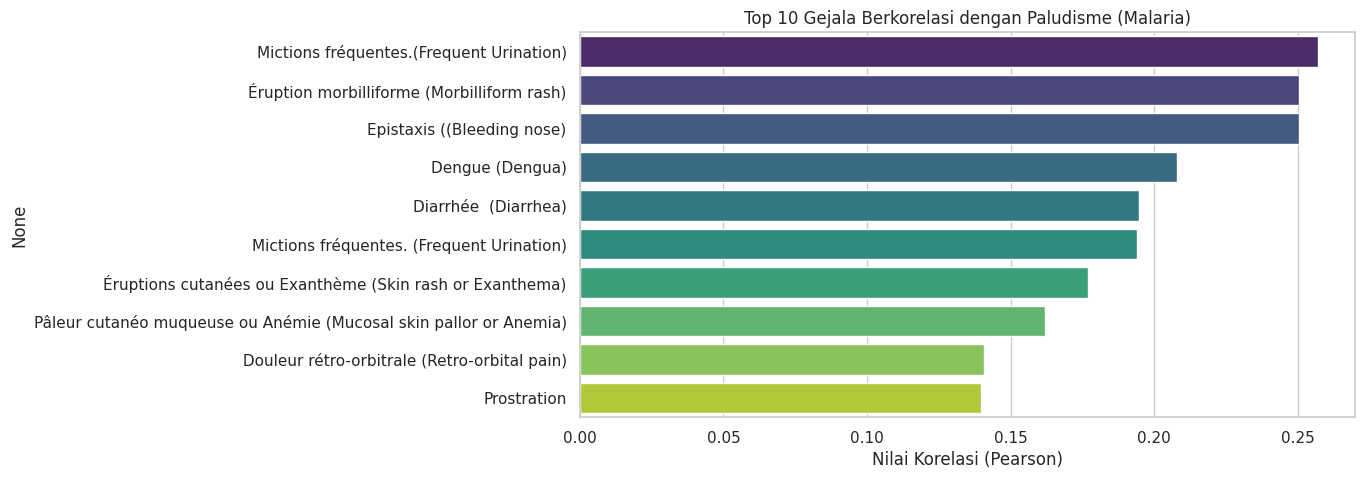

--- Top 10 Gejala Berkorelasi dengan Autres maladies diagnostiqué (Others diseases) ---


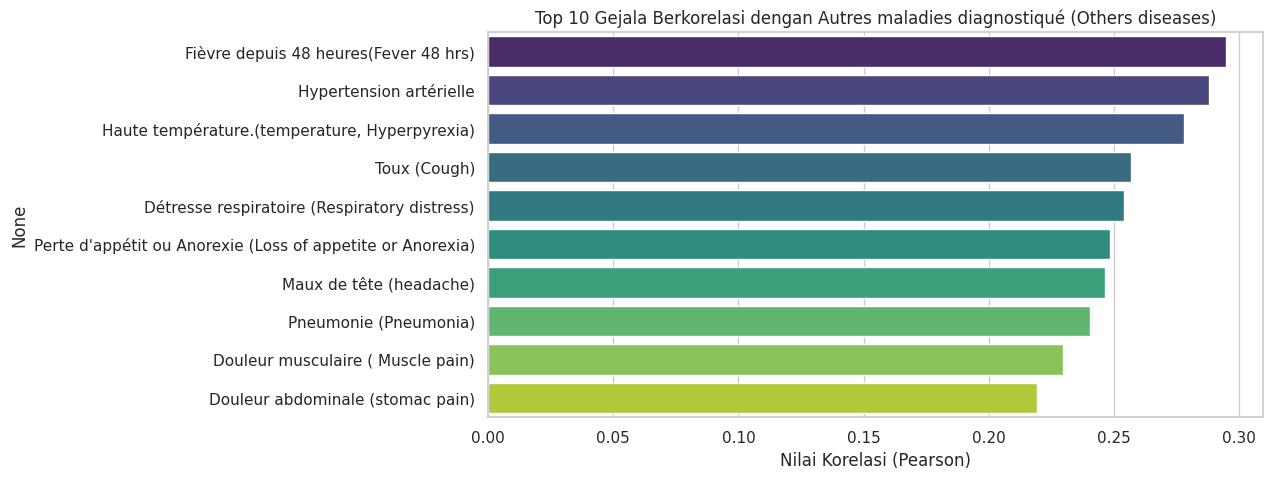

In [22]:
# Ambil 2 penyakit paling umum (Misal: Malaria dan Dengue)
top_targets = target_sums.index[:2] 

for target in top_targets:
    print(f'--- Top 10 Gejala Berkorelasi dengan {target.split("/")[-1]} ---')
    # Hitung korelasi target dengan semua kolom gejala
    correlations = df[symptom_cols + [target]].corr()[target].drop(target)
    
    # Ambil nilai absolut tertinggi
    top_10_corr = correlations.abs().sort_values(ascending=False).head(10)
    
    # Plotting
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_10_corr.values, y=top_10_corr.index, palette='viridis')
    plt.title(f'Top 10 Gejala Berkorelasi dengan {target.split("/")[-1]}')
    plt.xlabel('Nilai Korelasi (Pearson)')
    plt.show()


## 7. Correlation Heatmap (Target vs Top 15 Gejala)
Untuk melihat gambaran besar bagaimana penyakit dan gejala saling berhubungan secara simultan, kita akan menggunakan **Heatmap**. Karena jumlah gejala sangat banyak (79 gejala), kita hanya akan mengambil 15 gejala yang paling sering muncul agar visualisasinya tetap dapat dibaca dengan jelas.

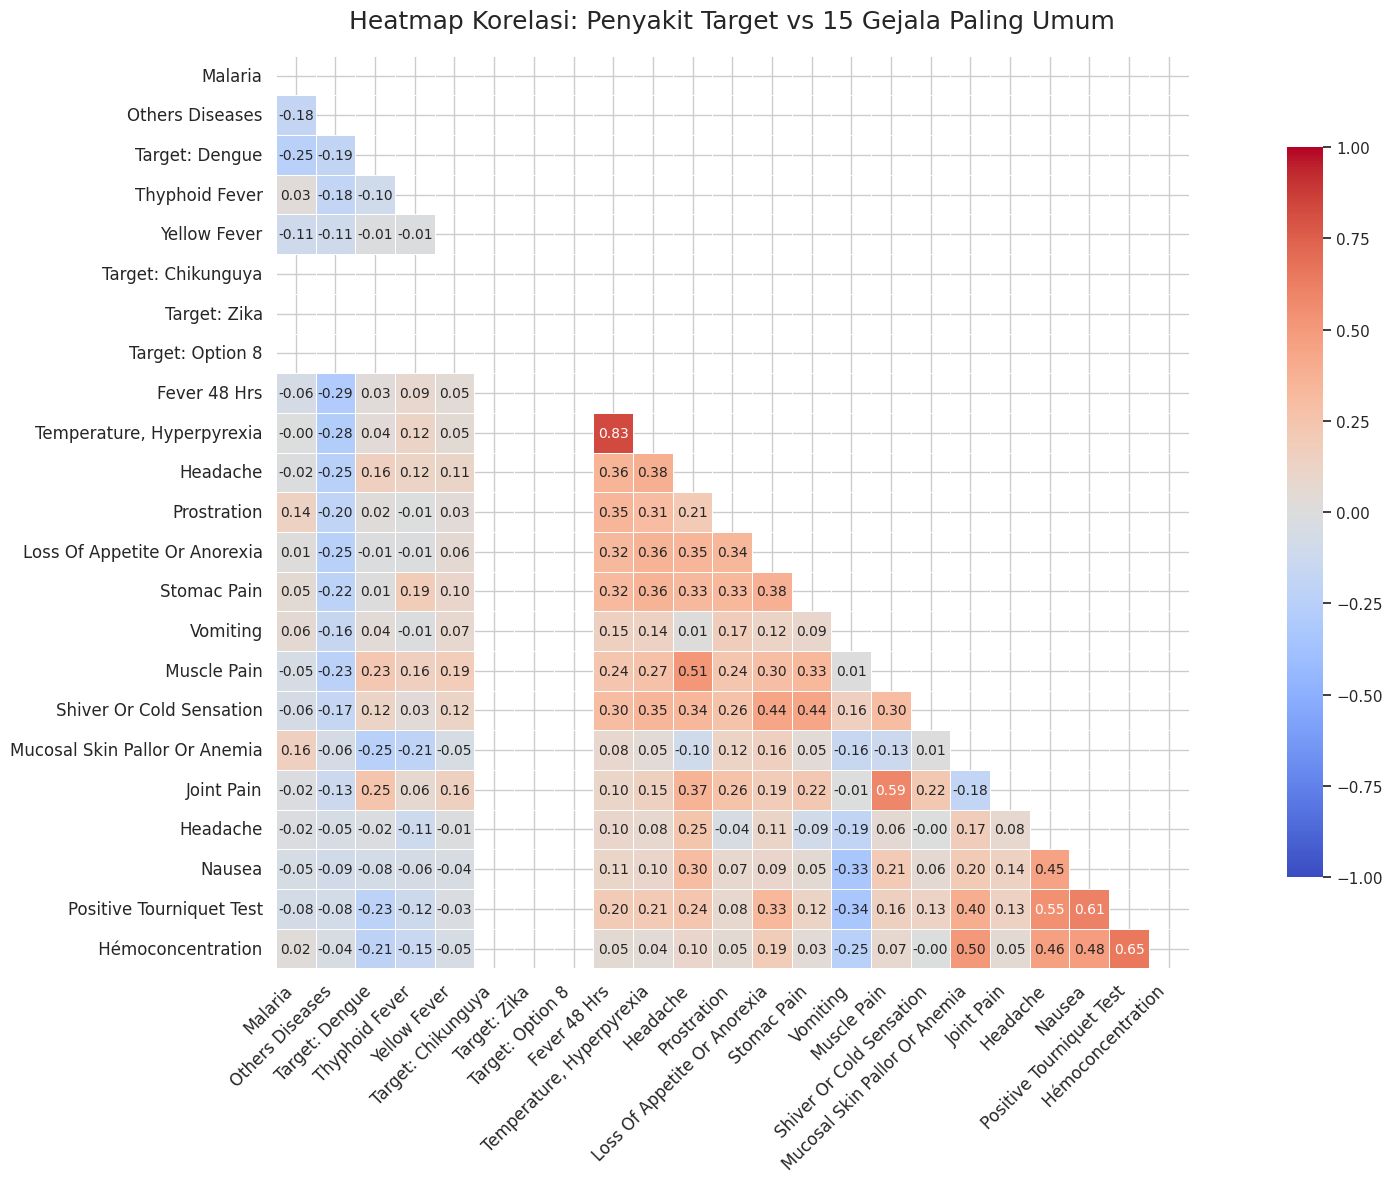

In [23]:
# 1. Cari 15 gejala yang paling sering muncul
top_15_symptoms = df[symptom_cols].sum().sort_values(ascending=False).head(15).index.tolist()

# 2. Gabungkan kolom Top 15 Gejala dengan Target Penyakit
heatmap_cols = list(target_sums.index) + top_15_symptoms

# 3. Hitung matriks korelasi
corr_matrix = df[heatmap_cols].corr()

# 4. MEMBERSIHKAN LABEL AGAR BISA DIBACA
def clean_label(text):
    # Hapus 'Maladies diagnostiquées/' jika ada
    text = text.replace('Maladies diagnostiquées/', 'Target: ')
    # Ambil teks di dalam kurung bahasa Inggris jika ada (contoh: 'Maux de tête (headache)' -> 'headache')
    import re
    match = re.search(r'\((.*?)\)', text)
    if match:
        return match.group(1).title()
    # Jika teks kepanjangan, potong
    if len(text) > 20:
        return text[:17] + '...'
    return text.title()

clean_labels = [clean_label(c) for c in heatmap_cols]
corr_matrix.index = clean_labels
corr_matrix.columns = clean_labels

# 5. Buat visualisasi Heatmap dengan ukuran lebih besar
plt.figure(figsize=(20, 12)) # Ukuran diperbesar

# Buat mask setengah segitiga bawah
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Sesuaikan parameter heatmap: ukuran font annot diperkecil, cbar disesuaikan
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={'shrink': .8},
            annot_kws={'size': 10})

plt.title('Heatmap Korelasi: Penyakit Target vs 15 Gejala Paling Umum', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()


## 8. Outlier Checking (Data Numerik)
Untuk memastikan tidak ada kesalahan input data (*Data Entry Error*) yang ekstrem, kita akan mengecek distribusi data numerik berkelanjutan yaitu **Umur** dan **Berat Badan** menggunakan Boxplot.
Ingat: Pada konteks medis pasca-bencana, outlier belum tentu data yang salah. Bisa jadi itu adalah kasus klinis ekstrem (misal balita gizi buruk). Kita hanya mencari anomali yang tidak masuk akal (seperti umur 200 tahun).

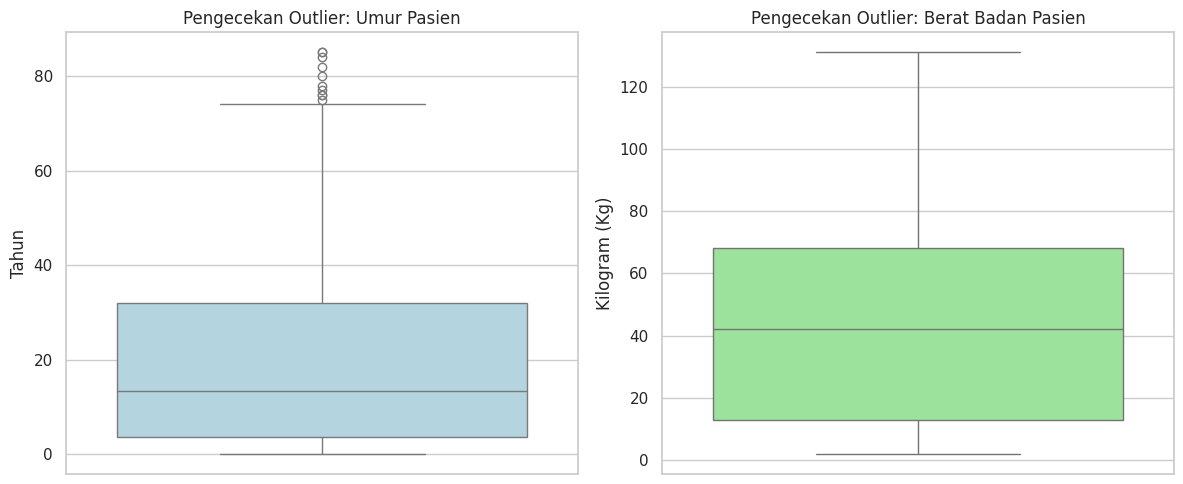

Statistik Deskriptif Numerik:


,Âge (Age),Poids (Weight)
count,300.000000,300.000000
mean,21.561233,40.716667
std,22.512704,27.408645
min,0.100000,2.000000
25%,3.600000,13.000000
50%,13.500000,42.000000
75%,32.000000,68.000000
max,85.000000,131.000000


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot untuk Umur
sns.boxplot(y=df['Âge (Age)'], ax=axes[0], color='lightblue')
axes[0].set_title('Pengecekan Outlier: Umur Pasien')
axes[0].set_ylabel('Tahun')

# Boxplot untuk Berat Badan
sns.boxplot(y=df['Poids (Weight)'], ax=axes[1], color='lightgreen')
axes[1].set_title('Pengecekan Outlier: Berat Badan Pasien')
axes[1].set_ylabel('Kilogram (Kg)')

plt.tight_layout()
plt.show()

# Menampilkan statistik deskriptif untuk meyakinkan tidak ada nilai absurd
print('Statistik Deskriptif Numerik:')
display(df[['Âge (Age)', 'Poids (Weight)']].describe())


## 9. Machine Learning Modeling Setup
Mempersiapkan data target (y) dan fitur (X) untuk pelatihan model. Kita juga akan membuat kolom `Is_Male` untuk keperluan evaluasi **Algorithmic Fairness** nanti.

In [25]:
# 1. Encoding Gender untuk Fairness Check (1 = Homme/Male, 0 = Femme/Female)
df['Is_Male'] = df['Genre (Gender)'].map(lambda x: 1 if str(x).strip().title() == 'Homme' else 0)

# 2. Menentukan Target (y)
target_cols = [c for c in df.columns if 'Maladies diagnostiquées/' in c]
y = df[target_cols]

# 3. Menentukan Features (X)
# Kita drop kolom target, dan kolom identitas/demografi string yang tidak dipakai model
cols_to_exclude = target_cols + ['Maladies diagnostiquées', 'Centre de santé', 'Age_Group', 'Genre (Gender)', '_uuid']
X = df.drop(columns=[c for c in cols_to_exclude if c in df.columns])

# [PERBAIKAN] One-Hot Encoding untuk kolom teks/kategorikal
# Model Random Forest Scikit-Learn membutuhkan semua data dalam bentuk angka.
# Kita mengubah sisa kolom teks (seperti 'Type de fièvre') menjadi kolom biner (0/1).
X = pd.get_dummies(X, drop_first=True)

# Pastikan tidak ada missing value atau nilai boolean yang tersisa
X = X.astype(float).fillna(0)

# 4. Split data: 80% Latih, 20% Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Ukuran Data Latih: {X_train.shape}')
print(f'Ukuran Data Uji: {X_test.shape}')

Ukuran Data Latih: (240, 1276)
Ukuran Data Uji: (60, 1276)


## 10. Melatih Model (One-Vs-Rest + Balanced Weights)
Menggunakan **Random Forest** dengan pendekatan **One-vs-Rest** untuk menangani multi-label (koinfeksi), ditambah parameter `class_weight='balanced'` agar model peka terhadap penyakit minoritas seperti Dengue.

In [26]:
# Inisialisasi Model
base_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
ovr_model = OneVsRestClassifier(base_rf)

# Melatih Model
ovr_model.fit(X_train, y_train)

# Prediksi Data Uji
y_pred = ovr_model.predict(X_test)

# Menampilkan Laporan Klasifikasi (Per Penyakit)
target_names = [t.split('/')[-1] for t in target_cols]
print('=== LAPORAN PERFORMA MODEL ===')
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


=== LAPORAN PERFORMA MODEL ===
                                                precision    recall  f1-score   support

                           Paludisme (Malaria)       0.98      1.00      0.99        58
                                        Dengue       1.00      0.57      0.73         7
                                    Chikunguya       0.00      0.00      0.00         0
                   Fièvre jaune (yellow fever)       0.00      0.00      0.00         2
              Fièvre Typhoïde (Thyphoid fever)       0.00      0.00      0.00         4
                                          Zika       0.00      0.00      0.00         0
Autres maladies diagnostiqué (Others diseases)       0.75      0.53      0.62        17
                                      Option 8       0.00      0.00      0.00         0

                                     micro avg       0.95      0.81      0.87        88
                                     macro avg       0.34      0.26      0.29        88

## 11. Evaluasi Algorithmic Fairness (Track IV Focus)
Membandingkan akurasi model antara pasien Laki-laki dan Perempuan untuk membuktikan bahwa algoritma kesehatan digital ini tidak memiliki bias (adil bagi seluruh populasi).

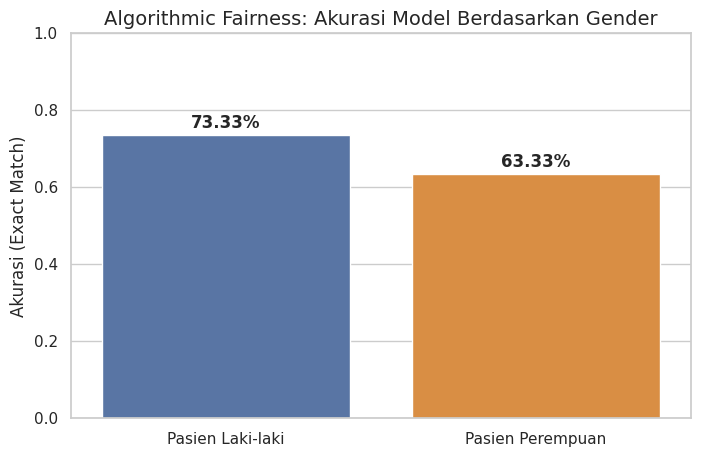

=== KESIMPULAN FAIRNESS ===
Model terbukti ADIL (Fair). Perbedaan performa antar gender sangat kecil (10.00%).


In [27]:
# Mengambil indeks untuk pasien laki-laki dan perempuan di data uji
idx_male = X_test['Is_Male'] == 1
idx_female = X_test['Is_Male'] == 0

# Ekstrak data uji dan prediksi berdasarkan gender
y_test_male = y_test[idx_male]
y_pred_male = y_pred[idx_male]

y_test_female = y_test[idx_female]
y_pred_female = y_pred[idx_female]

# Menghitung Akurasi Eksak
acc_male = accuracy_score(y_test_male, y_pred_male)
acc_female = accuracy_score(y_test_female, y_pred_female)

# Visualisasi Fairness
plt.figure(figsize=(8, 5))
sns.barplot(x=['Pasien Laki-laki', 'Pasien Perempuan'], y=[acc_male, acc_female], palette=['#4C72B0', '#F28E2B'])
plt.title('Algorithmic Fairness: Akurasi Model Berdasarkan Gender', fontsize=14)
plt.ylabel('Akurasi (Exact Match)')
plt.ylim(0, 1.0)

for i, v in enumerate([acc_male, acc_female]):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center', fontsize=12, fontweight='bold')

plt.show()

print('=== KESIMPULAN FAIRNESS ===')
diff = abs(acc_male - acc_female)
if diff < 0.1:
    print(f'Model terbukti ADIL (Fair). Perbedaan performa antar gender sangat kecil ({diff:.2%}).')
else:
    print(f'Terdapat Bias (Ketidakadilan). Perbedaan performa mencapai ({diff:.2%}).')


## 12. Hyperparameter Tuning with Optuna (Model Benchmarking)
Untuk mendapatkan performa maksimal, kita membandingkan 3 model:
1. **Logistic Regression:** Baseline medis yang interpretable.
2. **Random Forest:** Model Tree-based yang tangguh.
3. **XGBoost:** Algoritma pemenang kompetisi untuk tabular data.

Kita menggunakan **Optuna** (Bayesian Optimization) untuk mencari parameter terbaik, berfokus pada metrik makro (untuk mengatasi Class Imbalance).
*Catatan: Karena kita menggunakan `OneVsRestClassifier`, kita akan melakukan tuning pada base estimator-nya, namun untuk efisiensi komputasi di notebook ini, kita akan demonstrasikan tuning XGBoost secara langsung (yang sudah support multi-label natively jika menggunakan format yang tepat, atau kita wrap dengan OvR).*

In [29]:
# Menyiapkan fungsi objektif Optuna untuk Random Forest
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score
import numpy as np

np.random.seed(42)

# Kita gunakan F1-Macro agar model dihukum jika gagal menebak penyakit minoritas (Dengue)
f1_macro = make_scorer(f1_score, average='macro', zero_division=0)

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    
    base_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight='balanced',
        random_state=42
    )
    
    ovr = OneVsRestClassifier(base_model)
    
    # Validasi silang (Cross-Validation) dengan 3 lipatan (folds)
    score = cross_val_score(ovr, X_train, y_train, cv=3, scoring=f1_macro).mean()
    return score

print('Memulai Optuna Study untuk Random Forest...')
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10) # n_trials kecil untuk demo, bisa dinaikkan ke 50+ nanti
print(f'Parameter Terbaik Random Forest: {study_rf.best_params}')
print(f'F1-Macro Score Terbaik: {study_rf.best_value:.4f}')

# ==========================================
# Implementasi Model Terbaik dari Optuna
# ==========================================
print('--- MELATIH MODEL RANDOM FOREST TERBAIK ---')
best_rf = RandomForestClassifier(**study_rf.best_params, class_weight='balanced', random_state=42)
best_ovr = OneVsRestClassifier(best_rf)
best_ovr.fit(X_train, y_train)

y_pred_tuned = best_ovr.predict(X_test)
print(classification_report(y_test, y_pred_tuned, target_names=target_names, zero_division=0))


Memulai Optuna Study untuk Random Forest...
Parameter Terbaik Random Forest: {'n_estimators': 137, 'max_depth': 6, 'min_samples_split': 9}
F1-Macro Score Terbaik: 0.3185
--- MELATIH MODEL RANDOM FOREST TERBAIK ---
                                                precision    recall  f1-score   support

                           Paludisme (Malaria)       1.00      1.00      1.00        58
                                        Dengue       0.43      0.86      0.57         7
                                    Chikunguya       0.00      0.00      0.00         0
                   Fièvre jaune (yellow fever)       0.00      0.00      0.00         2
              Fièvre Typhoïde (Thyphoid fever)       0.29      0.50      0.36         4
                                          Zika       0.00      0.00      0.00         0
Autres maladies diagnostiqué (Others diseases)       0.71      0.59      0.65        17
                                      Option 8       0.00      0.00      0.00    